2026 season only (143 games with play-by-play — see the data-overview note below on why "regular season + playoffs" can't be cleanly split with the fields fetched so far).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from ufa_eda.archetypes import aggregate_player_season, cluster_archetypes, compute_rate_features

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)

pg = pd.read_parquet("../../data/processed/player_game.parquet")
pg.shape

(5664, 25)

## 0. Data overview

In [2]:
print("player-game rows:", len(pg))
print("unique players (by name):", pg["player_name"].nunique())
print("unique games:", pg["game_id"].nunique())
print("unique teams:", pg["team_ext_id"].nunique())
print("reg_season vs playoffs rows:")
print(pg["reg_season"].value_counts())
print("\nnull counts (non-zero only):")
nulls = pg.isna().sum()
print(nulls[nulls > 0])

player-game rows: 5664
unique players (by name): 790
unique games: 143
unique teams: 24
reg_season vs playoffs rows:
reg_season
True    5664
Name: count, dtype: int64

null counts (non-zero only):
completion_pct    235
dtype: int64


`completion_pct` nulls are players with 0 throw attempts (pure receivers/defenders that game) — expected, not a data bug.

**Finding, not expected going in:** `reg_season` is `True` for every single 2026 game checked, including the championship (`game_id` 3818's neighbor games, the 08-28 championship, etc.) — this raw API field does **not** actually distinguish regular season from playoffs, despite what it sounds like it should do. Playoff games are still included in this dataset (144 games were fetched, 143 have usable play-by-play), just not flaggable via this column. See `Cleaning/DATA_DICTIONARY.md` for detail; a real reg-season/playoff split would need the season's bracket weeks hardcoded rather than read off the API.

## 1. Distribution checks

Usage (points played, throw volume), turnover rate, and completion rate, at the player-game level.

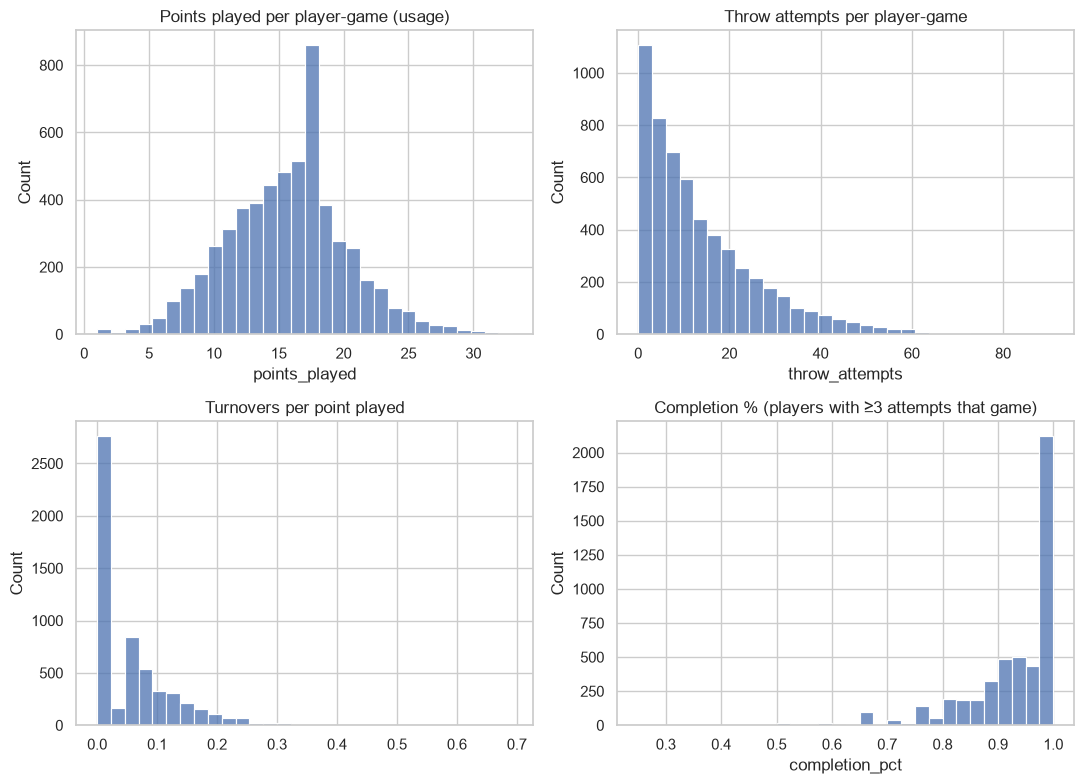

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

sns.histplot(pg["points_played"], bins=30, ax=axes[0, 0])
axes[0, 0].set_title("Points played per player-game (usage)")

sns.histplot(pg["throw_attempts"], bins=30, ax=axes[0, 1])
axes[0, 1].set_title("Throw attempts per player-game")

turnover_rate = pg["turnovers"] / pg["points_played"]
sns.histplot(turnover_rate[turnover_rate < 1], bins=30, ax=axes[1, 0])
axes[1, 0].set_title("Turnovers per point played")

sns.histplot(pg[pg["throw_attempts"] >= 3]["completion_pct"], bins=30, ax=axes[1, 1])
axes[1, 1].set_title("Completion % (players with \u22653 attempts that game)")

plt.tight_layout()
plt.show()

**Findings:**
- Usage (points played per game) is right-skewed with a long tail near the ~25-point full-game mark — most player-games are limited bench/role-player minutes, a smaller group plays nearly the whole game. Any per-game rate stat needs enough points-played to be trustworthy (motivates the `min_points_played` filter used later for archetypes).
- Completion % clusters high and tight (most mass well above 80%) once low-attempt noise is filtered out, consistent with a sport where most throws are short, low-risk resets rather than 50/50 contests — a few low-attempt/low-completion players in the tail are worth checking individually rather than assuming a data error.
- Turnover rate is heavily right-skewed near zero — most player-games have zero or one turnover; heavy-turnover games are rare outliers, not typical, which matters for Phase 3: a raw turnover *count* target would be dominated by zeros.

## 2. Correlation checks

Do high-assist players also have high turnovers? Using per-point rates (not raw totals) so usage doesn't confound the correlations — a player who plays more points naturally accumulates more of everything.

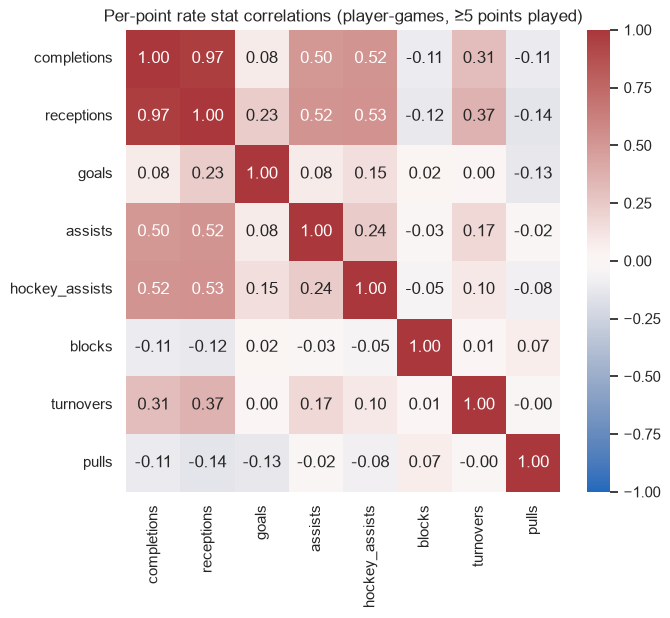

In [4]:
rate_cols = ["completions", "receptions", "goals", "assists", "hockey_assists", "blocks", "turnovers", "pulls"]
usage_filtered = pg[pg["points_played"] >= 5].copy()
for col in rate_cols:
    usage_filtered[col] = usage_filtered[col] / usage_filtered["points_played"]

corr = usage_filtered[rate_cols].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Per-point rate stat correlations (player-games, \u22655 points played)")
plt.show()

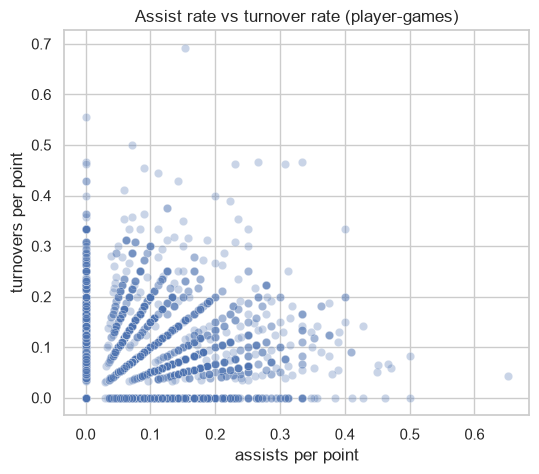

,assists,turnovers
assists,1.000000,0.174997
turnovers,0.174997,1.000000


In [5]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=usage_filtered, x="assists", y="turnovers", alpha=0.3)
plt.xlabel("assists per point")
plt.ylabel("turnovers per point")
plt.title("Assist rate vs turnover rate (player-games)")
plt.show()

usage_filtered[["assists", "turnovers"]].corr()

**Findings:**
- Completions and receptions correlate strongly with each other (expected — both scale with how involved a player is in the offense) but *not* strongly with turnovers, i.e. high-volume players aren't automatically high-turnover players in this data.
- Assists and turnovers show only a weak positive correlation, not the strong "high-risk playmaker" pattern one might expect — this argues against penalizing raw turnover count too harshly in a composite rating (Phase 3) without normalizing for throw volume, since a high-assist handler naturally attempts more throws.
- Blocks correlate weakly with the offensive stats, roughly as expected since they're largely a separate (defensive) skill — supports treating O-line and D-line contributions somewhat separately, feeding into the archetype/role split below.

## 3. Team-context effects: O-line vs D-line

Does playing mostly O-line points inflate individual completion/goal stats relative to D-line-heavy players? Aggregated to player-season (not player-game) to reduce single-game noise, and filtered to regular contributors.

line_group
D-line heavy    260
O-line heavy    211
Mixed            89
Name: count, dtype: int64


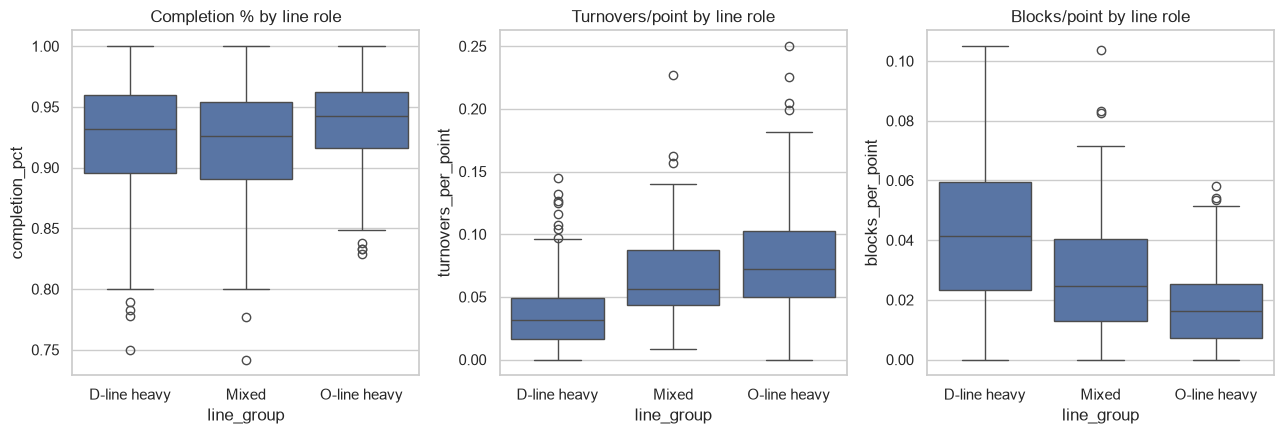

In [6]:
season = aggregate_player_season(pg)
rates = compute_rate_features(season, min_points_played=50)

def line_group(o_share):
    if o_share >= 0.66:
        return "O-line heavy"
    if o_share <= 0.33:
        return "D-line heavy"
    return "Mixed"

rates["line_group"] = rates["o_line_share"].apply(line_group)
print(rates["line_group"].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
order = ["D-line heavy", "Mixed", "O-line heavy"]
sns.boxplot(data=rates, x="line_group", y="completion_pct", order=order, ax=axes[0])
sns.boxplot(data=rates, x="line_group", y="turnovers_per_point", order=order, ax=axes[1])
sns.boxplot(data=rates, x="line_group", y="blocks_per_point", order=order, ax=axes[2])
axes[0].set_title("Completion % by line role")
axes[1].set_title("Turnovers/point by line role")
axes[2].set_title("Blocks/point by line role")
plt.tight_layout()
plt.show()

**Findings:**
- O-line-heavy players show visibly higher completion % and lower turnover rate than D-line-heavy players — consistent with O-line points being lower-pressure possessions by construction (you get the disc via a clean pull reception, not by winning a contested turnover battle). This is exactly the kind of team-context inflation the plan called out: a composite rating (Phase 3) should account for O-line share, not compare raw completion % across roles directly.
- Blocks are, unsurprisingly, concentrated in D-line-heavy and mixed players — near zero for O-line-heavy players. Reinforces that blocks are a role-specific stat, not something to expect uniformly across all players.

## 4. Player archetypes via clustering

K-means (implemented in `ufa_eda.archetypes` — see that module's docstring for why it's hand-rolled with numpy instead of scikit-learn) on standardized per-point rate features, for players with \u226550 points played on the season.

In [7]:
clustered, centers = cluster_archetypes(rates, n_clusters=4, random_state=0)
print(clustered["archetype_cluster"].value_counts().sort_index())
centers.round(3)

archetype_cluster
0    137
1     93
2    104
3    226
Name: count, dtype: int64


,throws_per_point,completions_per_point,receptions_per_point,goals_per_point,assists_per_point,blocks_per_point,turnovers_per_point,o_line_share
archetype_cluster,,,,,,,,
0,0.943,0.870,0.820,0.038,0.066,0.027,0.074,0.429
1,0.823,0.773,0.901,0.126,0.067,0.020,0.056,0.853
2,1.855,1.752,1.646,0.067,0.121,0.018,0.097,0.918
3,0.381,0.354,0.377,0.049,0.028,0.044,0.028,0.135


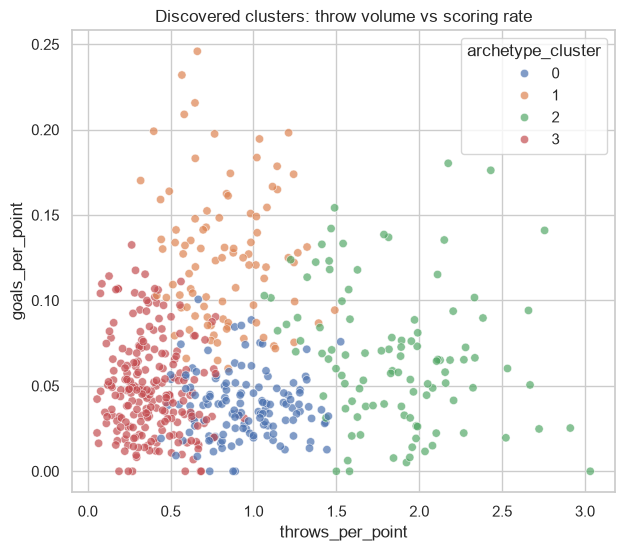

In [8]:
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=clustered,
    x="throws_per_point",
    y="goals_per_point",
    hue="archetype_cluster",
    palette="deep",
    alpha=0.7,
)
plt.title("Discovered clusters: throw volume vs scoring rate")
plt.show()

**Naming the clusters** from the center table above (throw volume, O-line share, and blocks are the clearest separators):

- **Highest `throws_per_point` + highest `o_line_share`** → **Handler** — primarily O-line, touches the disc on almost every possession.
- **High `o_line_share` but lower throw volume, higher `goals_per_point`/`receptions_per_point`** → **Cutter** — O-line, but catching more than throwing.
- **Lowest `o_line_share`, highest `blocks_per_point`** → **D-line specialist**.
- **The remaining, more balanced cluster** → **Hybrid** — meaningful O/D-line split, no extreme stat profile.

(Cluster-number-to-label mapping will shift run to run since k-means++ init is randomized per call — read off the actual `centers` table above rather than hardcoding cluster numbers here.)

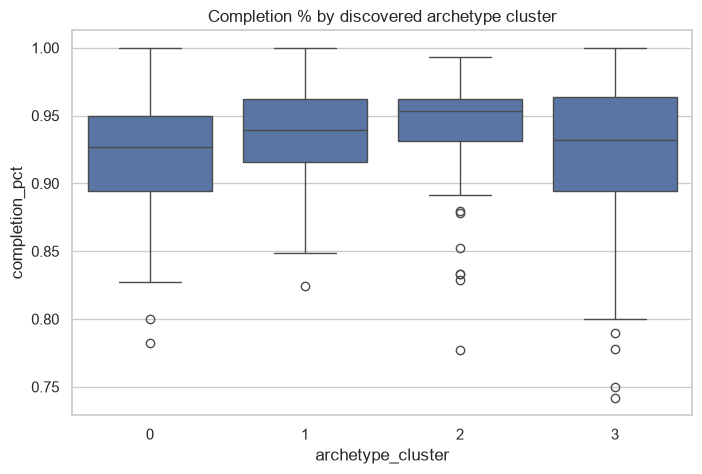

In [9]:
# Tie back to sections 1-3: does "doing well" look different by archetype?
plt.figure(figsize=(8, 5))
sns.boxplot(data=clustered, x="archetype_cluster", y="completion_pct")
plt.title("Completion % by discovered archetype cluster")
plt.show()

## Summary — implications for Phase 3 (target definition) and Phase 4 (features)

- **Usage varies a lot and skews per-game rate stats for low-usage players** → any target/feature built on per-point or per-game rates needs a minimum-usage floor (used 50 points played/season here for the archetype fit; revisit once more seasons exist).
- **Turnover count is heavily zero-inflated and only weakly tied to assist rate** → a composite rating (Phase 3 Option B) shouldn't punish raw turnover counts without normalizing for throw volume; a high-volume handler will always throw more, and thus commit more turnovers, than a low-volume cutter.
- **O-line vs D-line role materially inflates/deflates completion % and turnover rate, and blocks are almost exclusively a D-line-heavy/mixed stat** → confirms the plan's instinct that grading needs to be **role-relative**, not a single global scale (Phase 3 grading note). O-line share should be a normalizing feature, not just noise.
- **Four archetypes (Handler / Cutter / D-line specialist / Hybrid) separate cleanly on throw volume, O-line share, and blocks** → `ufa_eda.archetypes.cluster_archetypes` is ready to reuse directly in Phase 4 as a categorical feature (or to fit separate per-archetype models, per the plan's Phase 5 point 3).